# Graph Generation Strategy Comparison

This notebook explores the differences between three distinct graph generation strategies:
1. **Relative Neighborhood**: Relative Neighborhood Graph (RNG) approximation bounded by the K-nearest neighborhood.
2. **Standard KNN + Uniform Long-Range**: K-NN graph with `n` additional purely random uniform edges.
3. **Inverted KNN + Weighted Long-Range**: A target word is a neighbor to $k$ of its nearest neighbors, plus $n$ probabilistic long-range similarity-weighted edges.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.gridspec as gridspec

%matplotlib inline

In [4]:
# Load Data
try:
    df = pd.read_csv("data/results.csv")
    df = df[df["player"] == "greedy"]
    print(f"Loaded {len(df)} rows from compare_results.csv")
    display(df.head())
except FileNotFoundError:
    print("No compare_results.csv found.")


Loaded 49600 rows from compare_results.csv


,player,embedding,algorithm,k_nn,n_long,start,target,success,pth_len,opt_len,diff,path_str
0,greedy,gemini,relative_neighborhood,5,0,rescue,wife,False,-1,21,-1,rescue -> helping -> assistance -> assisted ->...
1,greedy,gemini,relative_neighborhood,5,0,disco,rome,False,-1,11,-1,disco -> disc -> disk -> plate -> plates -> di...
2,greedy,gemini,relative_neighborhood,5,0,repeated,healthy,False,-1,10,-1,repeated -> rep -> a -> sentence -> an -> sent...
3,greedy,gemini,relative_neighborhood,5,0,contact,cooking,False,-1,14,-1,contact -> communicate -> talking -> speaking ...
4,greedy,gemini,relative_neighborhood,5,0,oval,ratios,False,-1,7,-1,oval -> shape -> shapes -> geometry -> math ->...


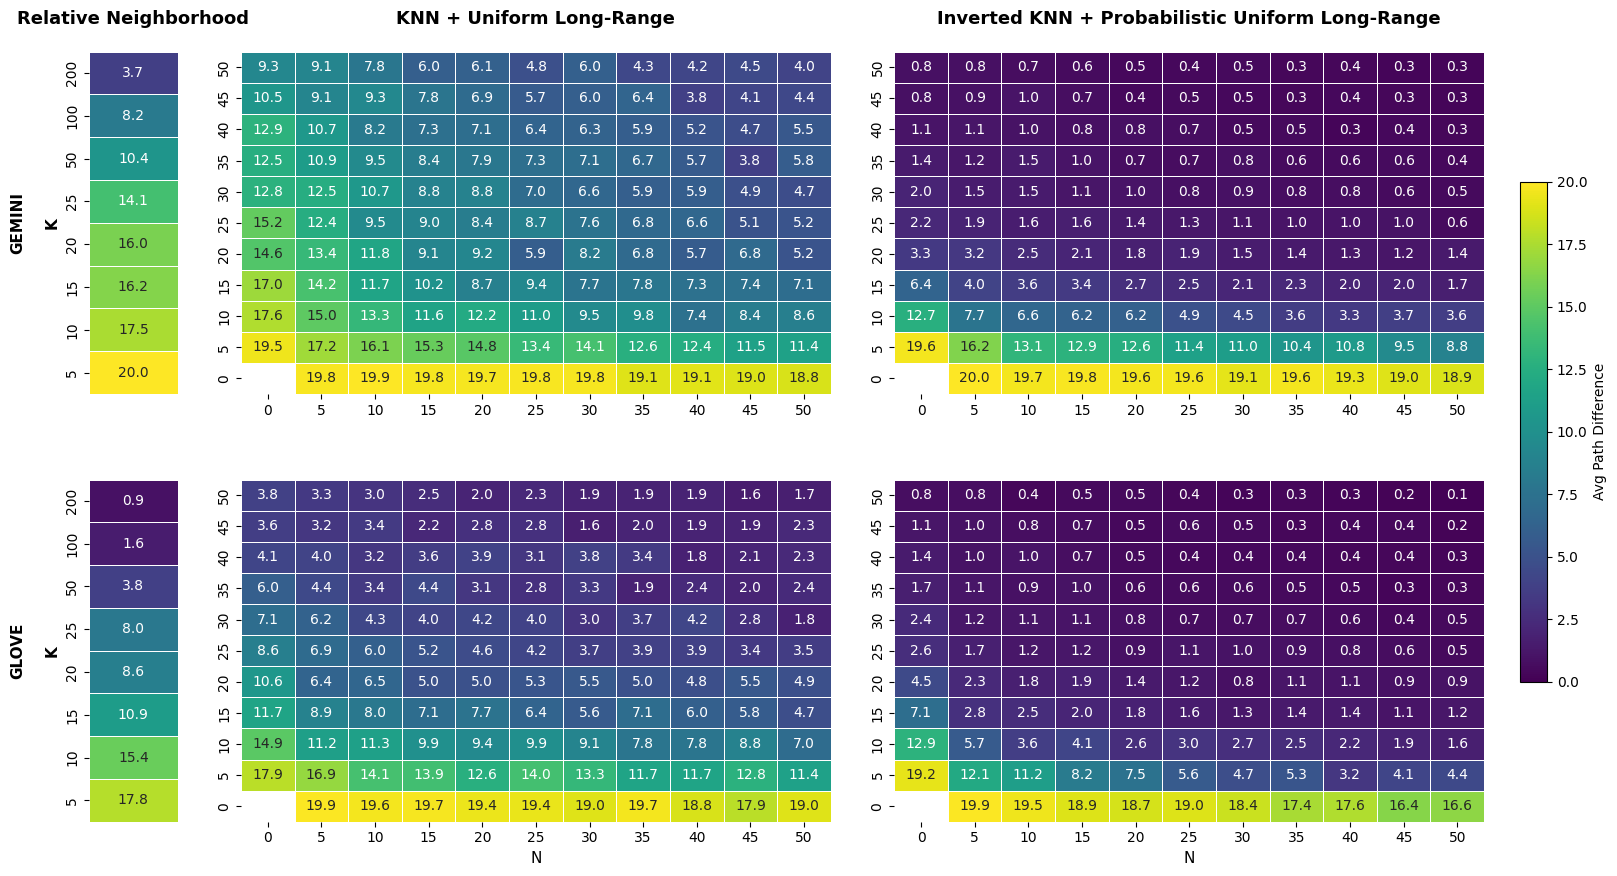

In [5]:
def prepare_heatmap_data(df, algo, embed):
    subset = df[(df['algorithm'] == algo) & (df['embedding'] == embed)].copy()
    if subset.empty: return pd.DataFrame()
    
    cols = ['k_nn', 'n_long', 'diff']
    subset[cols] = subset[cols].apply(pd.to_numeric, errors='coerce')
    subset['diff_adj'] = subset['diff'].replace(-1, 20).fillna(20)
    
    pivot = subset.groupby(['k_nn', 'n_long'])['diff_adj'].mean().unstack()
    return pivot.sort_index(ascending=False)

algos = [
    ('relative_neighborhood', 'Relative Neighborhood'),
    ('k_nn+n_random', 'KNN + Uniform Long-Range'),
    ('inv_knn+n_probabilistic', 'Inverted KNN + Probabilistic Uniform Long-Range')
]
embeddings = ['gemini', 'glove']

fig = plt.figure(figsize=(18, 10))
gs = gridspec.GridSpec(2, 3, width_ratios=[0.15, 1, 1], wspace=0.15, hspace=0.25)

heatmap_args = {
    'annot': True, 'fmt': '.1f', 'linewidths': 0.5, 
    'cmap': 'viridis', 'vmin': 0, 'vmax': 20, 'cbar': False
}

for row, embed in enumerate(embeddings):
    for col, (algo_id, title) in enumerate(algos):
        ax = fig.add_subplot(gs[row, col])
        data = prepare_heatmap_data(df, algo_id, embed)
        
        if not data.empty:
            sns.heatmap(data, ax=ax, **heatmap_args)
            
        if row == 0: 
            ax.set_title(title, fontsize=13, fontweight='bold', pad=20)
        
        if col == 0: 
            ax.set_ylabel(f"{embed.upper()}\n\nK", fontsize=11, fontweight='bold')
        else:
            ax.set_ylabel("")

        if row == 1 and col > 0:
            ax.set_xlabel("N", fontsize=11)
        else:
            ax.set_xlabel("")
            
        if col == 0:
            ax.set_xticks([])
            ax.set_xticklabels([])

cbar_ax = fig.add_axes([0.92, 0.25, 0.015, 0.5])
sm = plt.cm.ScalarMappable(cmap="viridis", norm=plt.Normalize(vmin=0, vmax=20))
fig.colorbar(sm, cax=cbar_ax, label='Avg Path Difference')

plt.show()